<a href="https://colab.research.google.com/github/mdaugherity/MachineLearning2026/blob/main/tutorial/Classification_Recipe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Dr. Daugherity, PHYS 453, Spring 2026**

# Classification Recipe
This notebook will give you basic outline for classification using best practices and more advanced tools from sklearn.    

## Workflow - The Order Is Important!

These are the steps:
1.  **Getting Data** - I really mention this as a step because in real-world problems you are likely to spend >80% of your time collecting, reading, exploring, and cleaning data.  
1.  **Preprocessing** - The first thing you do after getting data is to do **Test/Train Split**  to hide away a portion as your final test set.  Any data that has been *fit* cannot be used for a fair evaluation of the classifier's performance on new data.  Even something as simple as feature scaling can bias results. Also scale the data with **Transforms** and other feature engineering steps run in a **Pipeline**.

1.  **Training** - Tune all of the parameters with a cross-validation grid search.  Check for signs of under-fitting and over-fitting by comparing the training and validation scores.

1.  **Evaluating** - Only after you are completely done training your model, then you may run it on the saved test set to measure performance on new data.  

1. **Predicting** - Use your new model to actually do stuff!


**NOTES:** In the code below I will keep commentary to a minimum to reduce the amount of stuff you'll have to delete when using this code.  In each section I'll make a special cell for notes instead of sprinkling them everywhere.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Common Utilities
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

# Classifiers
from sklearn.svm import LinearSVC
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

# Data Set
In most machine learning problems with real-world data you can expect to spend >80% of your time on the project just dealing with the data sets.  I'm not going to cover cleaning and feature engineering here, but here are some issues to consider.

See Tutorial 10 for some more examples of all of these steps.

## Loading Data  
See the data loading utilities in the User's Guide here: https://scikit-learn.org/stable/datasets.html.  Common options:
* Pandas:  [read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html), [read_excel](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_excel.html), etc.  More options [here](https://pandas.pydata.org/pandas-docs/stable/reference/io.html)
* openml repository: [sklearn.datasets.fetch_openml](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_openml.html#sklearn.datasets.fetch_openml)
* Generated: use [sklearn generators](https://scikit-learn.org/stable/datasets/sample_generators.html) to follow my Golden Rule of Computing you should play with some data where you know the right answer  

In this notebook I'll assume we are starting with a Pandas dataframe.


## Cleaning Data
* Missing Data:
  * Pandas tools like [fillna](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.fillna.html#pandas.DataFrame.fillna) and [dropna](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.dropna.html#pandas.DataFrame.dropna).  See [Working with missing data](https://pandas.pydata.org/pandas-docs/stable/user_guide/missing_data.html) for more
  * sklearn can [impute missing values](https://scikit-learn.org/stable/modules/impute.html#impute) using tools like [SimpleInputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html#sklearn.impute.SimpleImputer)

* Making Numerical Features:
  * sklearn can [encode categorical features](https://scikit-learn.org/stable/modules/preprocessing.html#encoding-categorical-features) using [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html#sklearn.preprocessing.OrdinalEncoder) and [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html#sklearn.preprocessing.OneHotEncoder)
  * pandas similar functions are [factorize](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.factorize.html#pandas.factorize) and   [get_dummies](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html), see more [here](https://pandas.pydata.org/pandas-docs/stable/user_guide/reshaping.html#reshaping-dummies)
  * sklearn also has special tools for extracting features from [text](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction) and [images](https://scikit-learn.org/stable/modules/feature_extraction.html#image-feature-extraction)  

## Plotting Data
Make sure you understand the data you've got.  If you don't have too many features, it can be helpful to [make plots](https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html). This step is sometimes called expolatory data analysis (EDA).




## Load Dataframe
A quick example of loading and exploring a pandas dataframe.

In [3]:
data_bunch = datasets.load_breast_cancer(as_frame=True)

In [4]:
df = data_bunch['frame']
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.0750,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.5950,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


## Check Dataframe

In [5]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [6]:
df.dtypes  # check for non-numeric columns

,0
mean radius,float64
mean texture,float64
mean perimeter,float64
mean area,float64
mean smoothness,float64
mean compactness,float64
mean concavity,float64
mean concave points,float64
mean symmetry,float64
mean fractal dimension,float64


In [7]:
print('Number of NaN/null values:')
pd.isna(df).sum()

Number of NaN/null values:


,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


This dataset is pre-cleaned.  Everything is numeric and there are no missing values, so we can proceed.

## Convert to numpy
As of now, most of sklearn's classes can accept either numpy arrays or dataframes as input, so this step may not be necessary.   

Note that here we also could have used *return_X_y=True* when we loaded the dataset, but I wanted to show more of the process...

In [12]:
X = df[data_bunch.feature_names].to_numpy()
y = df['target'].to_numpy()



## Test/Train Split
Now we split data intro train and test subsets.  **IT IS IMPORTANT TO DO THIS FIRST** before any other operations take place.  I recommend reading through the [common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html) for more insights and discussion.
* only call fit on X_train
* only use X_test to evaulate the final accuracy

Use `stratify=y` to ensure proportional numbers of each target go to each set.

One important clarification: when we tell GridSearchCV to fit X_train, it tunes parameters by further splitting X_train into pieces to make training and [validation](https://en.wikipedia.org/wiki/Training,_validation,_and_test_data_sets) sets.  When we look at GridSearchCV "*test*" scores we are actually looking at portion of X_train, so it is best to call this the validation set.  We never let grid search see X_test until the final evaluation.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.2,stratify=y)

In [14]:
print('Train\t',X_train.shape)
print('Test\t',X_test.shape)

Train	 (455, 30)
Test	 (114, 30)


# Helper Functions
Define helper functions for plotting grid search results:


In [15]:
# These functions visualize results from a parameter grid search.

def make_grid_plot_labels(grid_clf):
  # Turns a parameter dictionary entry into a single string and returns the whole list
  res = grid_clf.cv_results_
  NUM_KEYS = len(res['params'][0].values())
  labels = []
  for item in res['params']:
    labels.append("_".join( [str(val) for val in item.values()]))
  return labels

def make_grid_plot(grid_clf):
  # Displays the scores for every set of parameters
  res = grid_clf.cv_results_
  plt.figure(figsize=(8,4))
  plt.axvline(grid_clf.best_index_, color='black', lw=2) # draw black line behind best params

  NUM_KEYS = len(res['params'])
  x = np.arange(NUM_KEYS)
  plt.plot(res['mean_test_score'],'-o', label='Val')
  plt.fill_between(x,res['mean_test_score']+res['std_test_score'], res['mean_test_score']-res['std_test_score'], alpha=0.2)
  #plt.errorbar(x, res['mean_test_score'],yerr=res['std_test_score'],xerr=0,fmt='-o', capsize=2, label='Val')

  plt.plot(res['mean_train_score'],'-s', label='Train')
  plt.fill_between(x,res['mean_train_score']+res['std_train_score'], res['mean_train_score']-res['std_train_score'], alpha=0.2)
  #plt.errorbar(x, res['mean_train_score'],yerr=res['std_train_score'],xerr=0,fmt='-s', capsize=2,label='Train')
  plt.title('Grid CV Results')
  plt.ylabel('Mean Test Score')

  labels = make_grid_plot_labels(grid_clf)
  plt.xticks(ticks = x, labels=labels, rotation=90)
  plt.legend()
  plt.grid()
  plt.show()

# Pipeline
The next steps will happen inside a [pipeline](https://scikit-learn.org/stable/modules/compose.html).  We need to scale the data (and possibly transform it in other exciting ways), and setting up a pipeline ensures that we will treat the test and train sets exactly the same way. See a simple example of pipeline usage [here](https://scikit-learn.org/stable/auto_examples/compose/plot_digits_pipe.html#sphx-glr-auto-examples-compose-plot-digits-pipe-py).



Remember that it is vital (for most classifiers) to scale the data first.  The other steps are optional and problem-specific.
* (required) Scaling: use [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler), [MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html#sklearn.preprocessing.MinMaxScaler), or [RobustScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html#sklearn.preprocessing.RobustScaler);  see the [User's Guide here](https://scikit-learn.org/stable/modules/preprocessing.html#standardization-or-mean-removal-and-variance-scaling)
* (optional): other transforms like dimensionality reduction using [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#sklearn.decomposition.PCA)

The last step in the pipeline will be the classifier. It is easier to make the pipeline all at once, so we'll do the pipeline code along with the classifiers below.




# Train

In [16]:
scores = dict()  # set up a variable to store the final scores

## LinearSVC
It is helpful to run a linear classifier or two because they are fast and easy while giving a good baseline to compare with more complex models.  

**References**
* User Guide: https://scikit-learn.org/stable/modules/svm.html#classification
* API: https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html#sklearn.svm.LinearSVC


**Parameters to know**
* ```C```: (default=1.0) regularization parameter, note that $C=1/\alpha$ so larger values give less regularization  

**Training Notes**
* We use linear models because they are fast and easy to train.  A small log search is normally sufficient.  

Grid Parameters: {'clf__C': array([1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00])}
Best parameters: {'clf__C': np.float64(0.01)}
Best Validation Score:	0.978


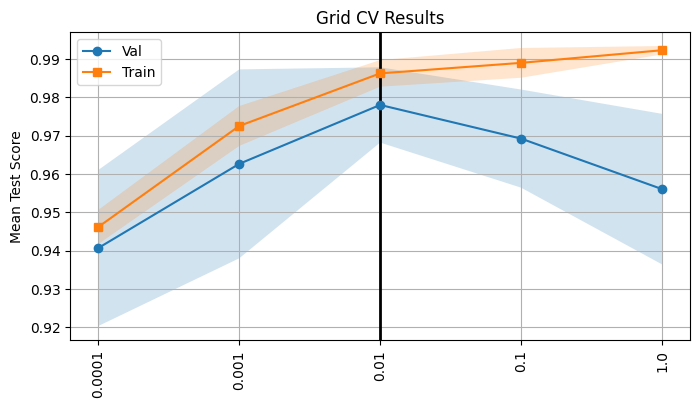

In [18]:
# Define Pipeline
estimators = [('scaler', StandardScaler()), ('clf', LinearSVC()) ]
pipe = Pipeline(estimators)

# Grid Search Parameters
CS = np.logspace(-4,0,5)
params = {'clf__C':CS}
print('Grid Parameters:',params)

grid_clf = GridSearchCV(pipe, param_grid=params, return_train_score=True)
grid_clf.fit(X_train, y_train)

print('Best parameters:', grid_clf.best_params_)
print(f"Best Validation Score:\t{grid_clf.best_score_:0.3f}")
scores['LinearSVC'] = grid_clf.best_score_

make_grid_plot(grid_clf)

## Linear - Ridge

It is helpful to run a linear classifier or two because they are fast and easy while giving a good baseline to compare with more complex models.  

Note that there is a RidgeClassifierCV which will do the grid search automatically.  Here I'm choosing to do the grid search myself for consistency with the other classifiers.

**References**
* User Guide: https://scikit-learn.org/stable/modules/linear_model.html#ridge-regression-and-classification
* API: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html
* API: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html


**Parameters to know**
* ```alpha```: (default=1.0) regularization parameter (larger values give more regularization)  

**Training Notes**
* We use linear models because they are fast and easy to train.  A small log search on alpha is normally sufficient.  






Grid Parameters: {'clf__alpha': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03])}
Best parameters: {'clf__alpha': np.float64(10.0)}
Best Validation Score:	0.956


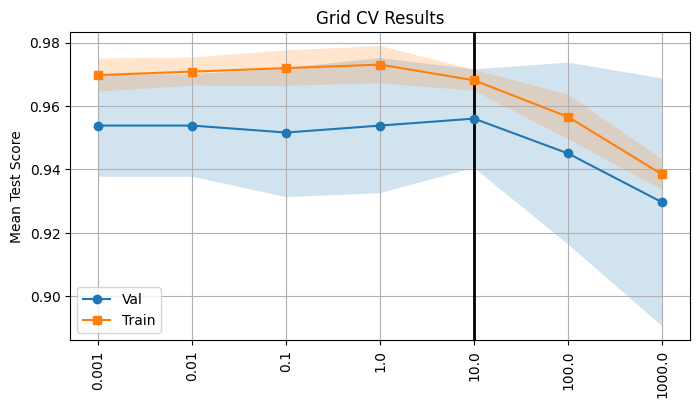

In [19]:
# Define Pipeline
estimators = [('scaler', StandardScaler()), ('clf', RidgeClassifier()) ]
pipe = Pipeline(estimators)

# Grid Search Parameters
ALPHAS = np.logspace(-3,3,7)
params = {'clf__alpha':ALPHAS}
print('Grid Parameters:',params)

grid_clf = GridSearchCV(pipe, param_grid=params, return_train_score=True)
grid_clf.fit(X_train, y_train)

print('Best parameters:', grid_clf.best_params_)
print(f"Best Validation Score:\t{grid_clf.best_score_:0.3f}")
scores['Ridge'] = grid_clf.best_score_

make_grid_plot(grid_clf)

## Stochastic Gradient Descent
It is helpful to run a linear classifier or two because they are fast and easy while giving a good baseline to compare with more complex models.  

**References**
* User Guide: https://scikit-learn.org/stable/modules/sgd.html#sgd
* API: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html#sklearn.linear_model.SGDClassifier

**Parameters to know**
* ```loss```: (default='hinge') options include: 'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron'

**Training Notes**
* Be wary that your answer can depend hugely on random values.  There are lots of options for controlling the search I'm not listing here.

Grid Parameters: {'clf__loss': ['hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron']}
Best parameters: {'clf__loss': 'perceptron'}
Best Validation Score:	0.967


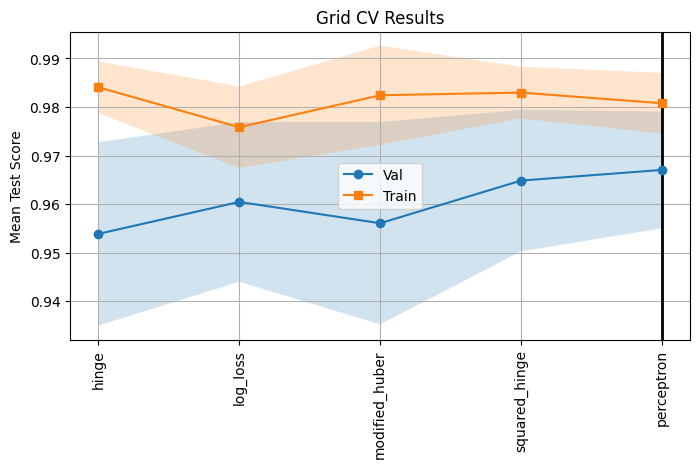

In [20]:
# Define Pipeline
estimators = [('scaler', StandardScaler()), ('clf', SGDClassifier(random_state=0)) ]
pipe = Pipeline(estimators)

# Grid Search Parameters
loss_funs = ['hinge', 'log_loss', 'modified_huber','squared_hinge','perceptron']
params = {'clf__loss':loss_funs}
print('Grid Parameters:',params)

grid_clf = GridSearchCV(pipe, param_grid=params, return_train_score=True)
grid_clf.fit(X_train, y_train)

print('Best parameters:', grid_clf.best_params_)
print(f"Best Validation Score:\t{grid_clf.best_score_:0.3f}")

make_grid_plot(grid_clf)

##Support Vector Machines

Works by ignoring every data point except those near the boundary (aka the 'support vectors') and tries to maximize the distance.  Can use the kernel trick to add non-linear features to a linear classifier.

**References**
* User Guide: https://scikit-learn.org/stable/modules/svm.html
* API: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC

**Parameters to know**
* ```kernel```: Default is 'rbf', options are ['linear', 'poly', 'rbf', 'sigmoid'].  
* ```degree```=3, only used for poly kernel
* ```C```=1.0, L2 regularization parameter, C is inverse of alpha so larger values give less regularization

**Training Notes**
* If the dataset is very large consider switching to LinearSVC for faster performance




Grid Parameters: {'clf__kernel': ['linear', 'poly', 'rbf', 'sigmoid']}
Best parameters: {'clf__kernel': 'rbf'}
Best Validation Score:	0.980


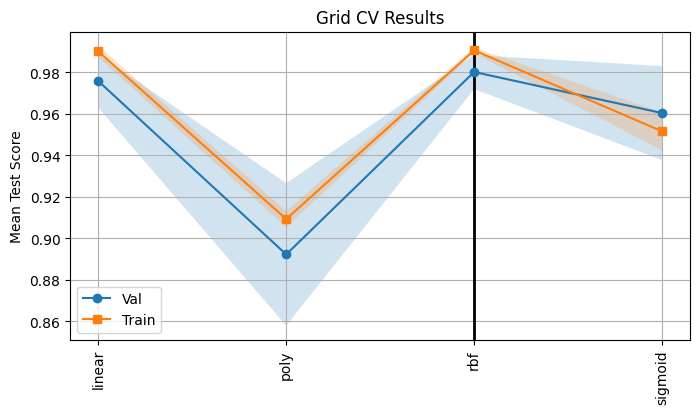

In [21]:
# Define Pipeline
estimators = [('scaler', StandardScaler()), ('clf', SVC()) ]
pipe = Pipeline(estimators)

# Grid Search Parameters
params = {'clf__kernel': ['linear', 'poly', 'rbf', 'sigmoid'] }
print('Grid Parameters:',params)

grid_clf = GridSearchCV(pipe, param_grid=params, return_train_score=True)
grid_clf.fit(X_train, y_train)

print('Best parameters:', grid_clf.best_params_)
print(f"Best Validation Score:\t{grid_clf.best_score_:0.3f}")
scores['SVM'] = grid_clf.best_score_

make_grid_plot(grid_clf) # Plot the results

## Nearest Neighbors

**References**
* User Guide: http://scikit-learn.org/stable/modules/neighbors.html#nearest-neighbors
* API: http://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html


**Parameters to know**
* ```n_neighbors```: also known as *k*, the number of neighbors. Default is 5
* ```weights```={‘uniform’, ‘distance’}: distance probably works better, but it is annoying that the validation score is always 1

**Training Notes**
* k=1 overfits while large values of k (close to N) underfits
* The training score is also always 1 for k=1 (unless there is a tie) or for distance weights
* Start with k=1 and increase to a large enough value that you see a peak in the validation scores
* You can try both options for ```weights``` or just use distance




Grid Parameters: {'clf__n_neighbors': array([ 5,  7,  9, 11, 13, 15, 17, 19, 21, 23])}
Best parameters: {'clf__n_neighbors': np.int64(13)}
Best Validation Score:	0.963


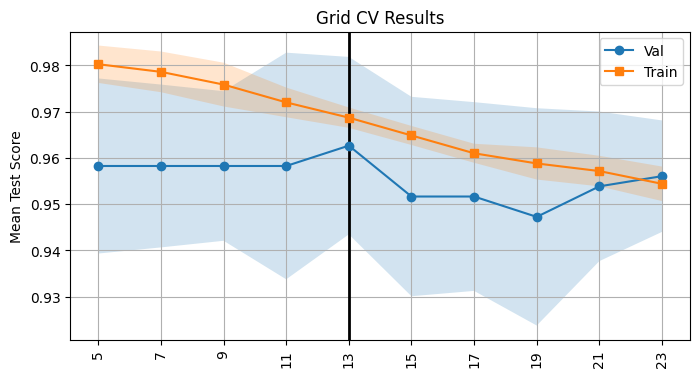

In [24]:
# Define Pipeline
estimators = [('scaler', StandardScaler()), ('clf', KNeighborsClassifier()) ]
pipe = Pipeline(estimators)

# Grid Search Parameters
#KLIST = np.arange(1,11)
KLIST = np.arange(5,25,2)
params = {'clf__n_neighbors':KLIST} # one par
#WLIST = ['uniform','distance']
#params = {'clf__n_neighbors':KLIST, 'clf__weights':WLIST} # two pars

print('Grid Parameters:',params)

grid_clf = GridSearchCV(pipe, param_grid=params, return_train_score=True)
grid_clf.fit(X_train, y_train)

print('Best parameters:', grid_clf.best_params_)
print(f"Best Validation Score:\t{grid_clf.best_score_:0.3f}")
scores['KNeighbors'] = grid_clf.best_score_

make_grid_plot(grid_clf)

## Decision Tree

**References**
* User Guide: https://scikit-learn.org/stable/modules/tree.html#tree
* API: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html


**Parameters to know**
* ```max_depth```: Tree grows until the training score is 1 or max_depth is reached.  Default is *none* which will overfit.

**Training Notes**
* Increase max_depth until the train score is 1.00, this is the tree's true maximum depth and there is no point in going any higher
* In event of a tie when choosing features for the next split it will make a random choice.  Set `random_state` if you want consistent behavior
* The tree's performance is not affected by scaling the data.  If you want to make tree plots later, then you can just use **UN**scaled data for the tree.



Grid Parameters: {'clf__max_depth': array([1, 2, 3, 4, 5, 6, 7])}
Best parameters: {'clf__max_depth': np.int64(4)}
Best Validation Score:	0.949


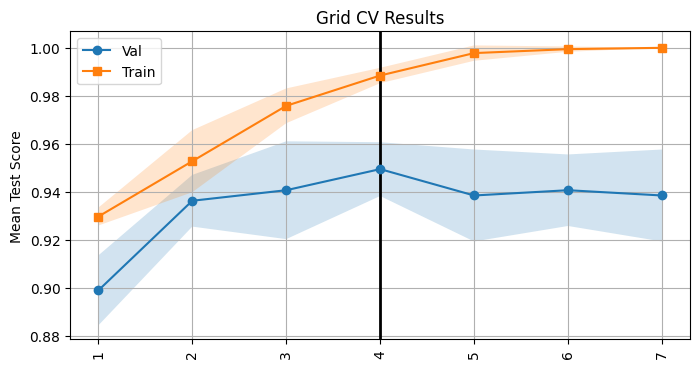

In [26]:
# Define Pipeline
estimators = [('scaler', StandardScaler()), ('clf', DecisionTreeClassifier(random_state=0)) ]
pipe = Pipeline(estimators)

# Grid Search Parameters
DEPTHS = np.arange(1,8)
params = {'clf__max_depth':DEPTHS}
print('Grid Parameters:',params)

grid_clf = GridSearchCV(pipe, param_grid=params, return_train_score=True)
grid_clf.fit(X_train, y_train)

print('Best parameters:', grid_clf.best_params_)
print(f"Best Validation Score:\t{grid_clf.best_score_:0.3f}")
scores['DecisionTree'] = grid_clf.best_score_

make_grid_plot(grid_clf) # Plot the results

## Gradient Boosted Trees
In sklearn we get two implementations:
1.  **GradientBoostingClassifier** is a bit more accurate (especially for small number of data samples) but slower
1.  **HistGradientBoostingClassifier** is orders of magnitude faster and has built-in support for missing values, but a tiny bit less accurate.  


They are similar but annoyingly different to use.
I'll only use the fast HistGBC here.  (If you want to use the other one see my tutorial for details on the parameters)


**References**
* Users Guide: https://scikit-learn.org/stable/modules/ensemble.html#gradient-boosted-trees
* HGBC API: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html

**Parameters to Know**
* ```max_iter```=100, main parameter, fairly robust to overfitting so a "large number" usually gives better performance.  Can run with large value to plot learning curve, then manually set this to cut off before overfitting.
* ```learning_rate``` = 0.1, trade-off between learning_rate and n_estimators.  Each new learner is scaled by learning_rate, so smaller rate needs more learners
* ```early_stopping```='auto', auto enables early stopping when sample size>10k
* ```n_iter_no_change```=10: only used when early stopping
* ```validation_fraction```=0.1, only used if early_stopping
* ```tol```=1e-7: only used if early_stopping

**Training Notes**
The recommended approach is easy:
* ```learning_rate```=0.1 (this is the default)
* enable early stopping
* add enough trees so that early stopping happens
* no grid search needed (but still use pipeline and scalar), but still can use it


n_estimators asked:   200
n_estimators used:    151
max val score n_iter= 141


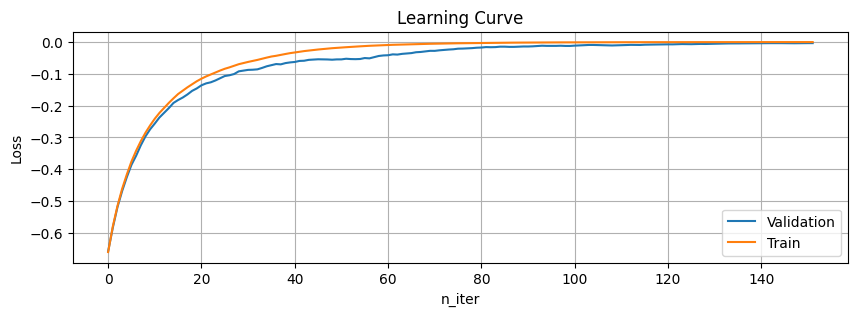

In [28]:
# Optional Step 1 - Run once without grid search to plot learning curve, make sure max_iter is large enough
estimators = [('scaler', StandardScaler()),
 ('clf', HistGradientBoostingClassifier(max_iter=200, early_stopping=True, random_state=0)) ]

pipe = Pipeline(estimators)
pipe.fit(X_train,y_train)
print('n_estimators asked:  ', pipe[-1].max_iter)
print('n_estimators used:   ', pipe[-1].n_iter_)
print('max val score n_iter=',pipe[-1].validation_score_.argmax())

plt.figure(figsize=(10,3))
plt.plot(pipe[-1].validation_score_,label='Validation')
plt.plot(pipe[-1].train_score_,label='Train')
plt.legend()
plt.title('Learning Curve')
plt.xlabel('n_iter')
plt.ylabel('Loss')
plt.grid()
plt.show()

Grid Parameters: {'clf__max_iter': [20, 50, 100, 150]}
Best parameters: {'clf__max_iter': 50}
Best Validation Score:	0.963


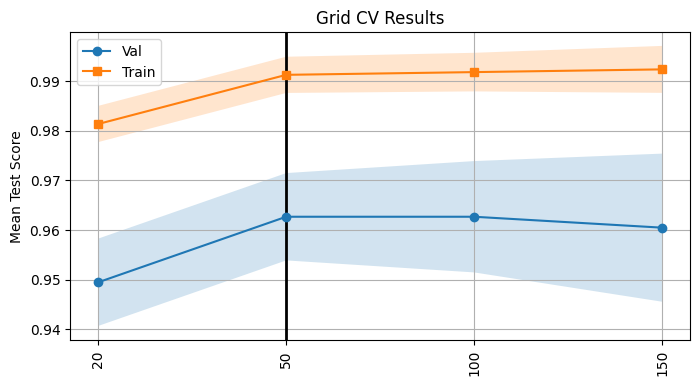

In [35]:
# Define Pipeline
estimators = [('scaler', StandardScaler()),
 ('clf', HistGradientBoostingClassifier(early_stopping=True, verbose=0, random_state=0)) ]

pipe = Pipeline(estimators)

# Grid Search Parameters
params = {'clf__max_iter':[20,50,100,150]}
print('Grid Parameters:',params)

grid_clf = GridSearchCV(pipe, param_grid=params, return_train_score=True)
grid_clf.fit(X_train, y_train)

print('Best parameters:', grid_clf.best_params_)
print(f"Best Validation Score:\t{grid_clf.best_score_:0.3f}")
scores['Hist GBC Tree'] = grid_clf.best_score_

make_grid_plot(grid_clf) # Plot the results

## Neural Network

References:
* User's Guide - http://scikit-learn.org/stable/modules/neural_networks_supervised.html
* API - http://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

Notes:
* Each run starts with **random** weights.  Remove random_state if you want different results every time
* Ideally you will have 5-10 training samples per weight.  So for a single hidden layer the number of features times the number of hidden nodes should not exceed 20% of the number of training samples.  Here we have 4 features and 120 samples,  so we can't expect reliable results for much more than 20 nodes
* Adding parameter options makes the grid search **EXPONENTIALLY** longer.  Start with just hidden nodes to narrow down a range, then add activation function or others
* To suppress warnings add this code above the grid search (make sure to indent):
```
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning, module="sklearn")
```



Grid Parameters: {'clf__hidden_layer_sizes': array([ 3,  4,  5,  6,  7,  8,  9, 10])}
Best parameters: {'clf__hidden_layer_sizes': np.int64(4)}
Best Validation Score:	0.982


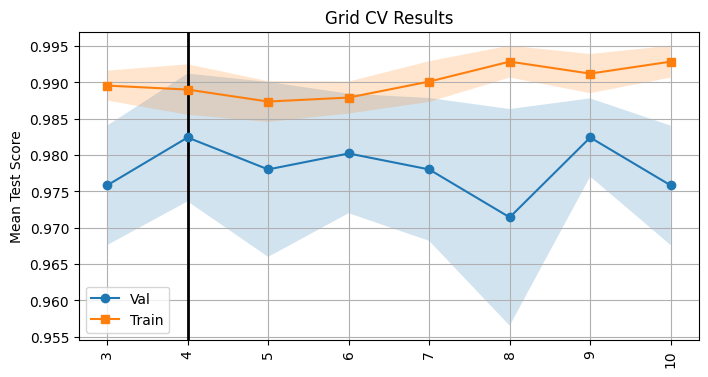

In [37]:
# Define Pipeline
estimators = [('scaler', StandardScaler()), ('clf', MLPClassifier(max_iter=2000, random_state=0)) ]
pipe = Pipeline(estimators)

# Grid Search Parameters
params = {'clf__hidden_layer_sizes': np.arange(3,11)}   # start with something like this for single layer
#params = {'clf__hidden_layer_sizes': [(4),(6),(8),(10),(2,2),(3,3),(4,4)]}   # 2 layer example
#params = {'clf__hidden_layer_sizes': [(5),(10),(3,3),(4,4)],  'clf__activation': ['tanh', 'relu'] } # varying activation functions
print('Grid Parameters:',params)

grid_clf = GridSearchCV(pipe, param_grid=params, return_train_score=True)
grid_clf.fit(X_train, y_train)

print('Best parameters:', grid_clf.best_params_)
print(f"Best Validation Score:\t{grid_clf.best_score_:0.3f}")
scores['NeuralNetwork'] = grid_clf.best_score_

make_grid_plot(grid_clf) # Plot the results

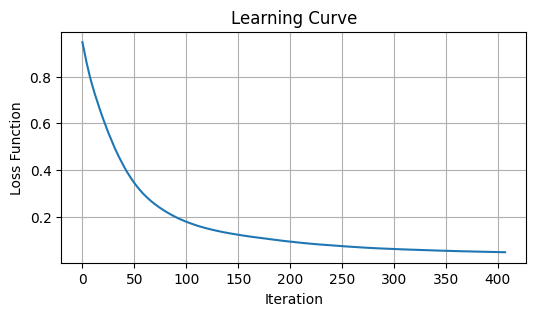

In [38]:
plt.figure(figsize=(6,3))
clf = grid_clf.best_estimator_[-1]
plt.plot(clf.loss_curve_)
plt.ylabel('Loss Function')
plt.xlabel('Iteration')
plt.title('Learning Curve')
plt.grid()
plt.show()

# Final Summary

In [39]:
print('Validation Scores:')
for k,v in scores.items():
  print(f"{k:15}{v:0.3f}")

Validation Scores:
LinearSVC      0.978
Ridge          0.956
SVM            0.980
KNeighbors     0.963
DecisionTree   0.949
Hist GBC Tree  0.963
NeuralNetwork  0.982


Sorted Validation Scores:
NeuralNetwork  0.982
SVM            0.980
LinearSVC      0.978
KNeighbors     0.963
Hist GBC Tree  0.963
Ridge          0.956
DecisionTree   0.949


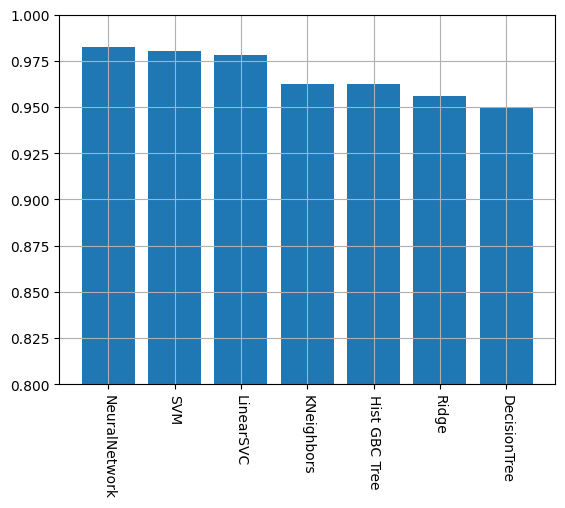

In [42]:
sorted_scores = sorted(scores.items(), key=lambda item: item[1], reverse=True)
print('Sorted Validation Scores:')
for s in sorted_scores:
  print(f"{s[0]:15}{s[1]:0.3f}")


x = np.arange(len(scores))
s = [s[1] for s in sorted_scores]
labels = [s[0] for s in sorted_scores]
plt.bar(x,s,width=0.8)
plt.xticks(ticks=x, labels=labels,rotation=-90)
plt.ylim(0.8,1)
plt.grid()
plt.show()

# Evaluate
**NOTES**

* Do not run this code until you are done training your model
* Don't have data leakage.  Do not go back and adjust options to improve test scores

In [44]:
# Put your winner in here
estimators = [('scaler', StandardScaler()), ('clf', MLPClassifier(hidden_layer_sizes=4, max_iter=2000, random_state=0)) ]
final_clf = Pipeline(estimators)

final_clf.fit(X_train, y_train)

print(f"Validation Score:\t{grid_clf.best_score_:0.3f}")

Validation Score:	0.982


In [46]:
# Only run this one time after you are completely done
print(f"Grid Test SCORE:\t{final_clf.score(X_test,y_test):0.3f}")

Grid Test SCORE:	0.965


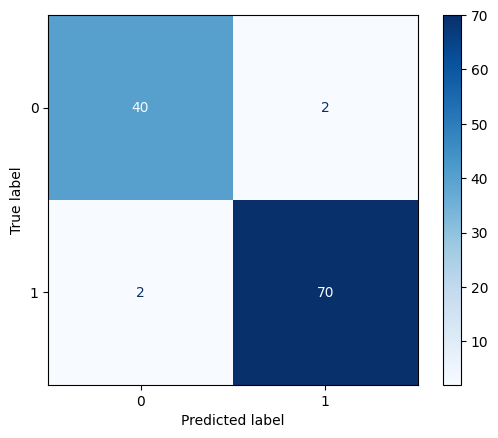

In [48]:
y_pred = final_clf.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.show()

In [49]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        42
           1       0.97      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114

